In [1]:
import torch
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from datasets import load_dataset
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import os
from diffusers import DiffusionPipeline
from transformers import CLIPProcessor, CLIPModel
import random


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [2]:

device = "cuda" if torch.cuda.is_available() else "cpu"

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

output_dir = "generated_images"
os.makedirs(output_dir, exist_ok=True)

print("Device:", device)

Device: cuda


In [3]:
pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    use_safetensors=True
)
pipe.to(device)

pipe.enable_attention_slicing()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [4]:
prompts = {
    "level1": [
        "A cinematic photograph of an old fisherman standing on a wooden dock at sunrise,\
         wearing a weathered blue raincoat and rubber boots, holding a fishing net full of silver fish,\
          with seagulls flying overhead, gentle waves reflecting golden sunlight,\
           distant mountains covered in light morning mist, highly detailed textures,\
          natural lighting, shallow depth of field",
        "Ultra-detailed street photography of a busy Tokyo market at night, neon signs in Japanese characters, vendors selling colorful seafood and fresh vegetables, people holding transparent umbrellas under light rain, reflections on wet asphalt, soft cinematic lighting, 85mm lens, high dynamic range",
        "A realistic medieval blacksmith workshop interior, glowing forge with bright orange sparks, muscular blacksmith hammering a sword on an anvil, stone walls covered in tools, wooden beams overhead, smoke particles in the air, warm dramatic lighting, hyper-detailed textures",
        "Professional wildlife photography of a snow leopard walking across a rocky Himalayan cliff, wind blowing through its fur, distant snowy peaks under a cloudy sky, dramatic natural lighting, ultra-high detail, National Geographic style",
        "Interior of a cozy vintage library café, wooden bookshelves filled with old books, warm yellow lamps, a woman reading by the window with coffee steam rising, rain outside the glass, soft cinematic atmosphere, highly realistic rendering"
    ],
    "level2": [
        "A transparent glass elephant filled with glowing bioluminescent jellyfish, walking through a flooded Renaissance cathedral, sunlight refracting through stained glass windows, reflections on water, floating candles, cinematic volumetric lighting, ultra-detailed textures",
        "A futuristic city built inside the branches of a colossal ancient tree, flying vehicles shaped like origami birds, waterfalls flowing between wooden skyscrapers, holographic advertisements in the air, children riding mechanical deer, hyper-realistic, ultra-detailed",
        "An astronaut wearing a Victorian-era suit made of brass and velvet, standing inside a giant hourglass where galaxies replace sand, planets orbiting around him, cosmic dust particles glowing, dramatic chiaroscuro lighting, high-resolution detail",
        "A surreal underwater library where books float like jellyfish, glowing ink flowing from open pages, mermaids wearing modern business suits typing on coral keyboards, beams of sunlight piercing deep ocean water, ultra-realistic textures",
        "A surreal underwater library where books float like jellyfish, glowing ink flowing from open pages, mermaids wearing modern business suits typing on coral keyboards, beams of sunlight piercing deep ocean water, ultra-realistic textures"
    ],
    "level3": [
        "A visual representation of time arguing with gravity inside a collapsing cathedral made of mathematical equations, floating fragments of shattered clocks transforming into birds, light bending into impossible geometric patterns, hyper-detailed, surreal, cinematic realism",
        "A visual representation of time arguing with gravity inside a collapsing cathedral made of mathematical equations, floating fragments of shattered clocks transforming into birds, light bending into impossible geometric patterns, hyper-detailed, surreal, cinematic realism",
        "A portrait of entropy wearing a crown made of melting stars, standing on a staircase that spirals into infinity, shadows detaching from objects and forming independent beings, highly detailed, impossible physics, dramatic lighting",
        "A courtroom where abstract concepts like justice, fear, and probability appear as physical entities made of light and glass, debating in a space where the floor is a flowing ocean of numbers, ultra-realistic textures, cinematic atmosphere",
        "A universe dreaming about its own creation, galaxies forming brush strokes in a cosmic painting, mathematical constants floating as luminous symbols, reality folding into recursive mirrors, hyper-detailed surreal visualization"
    ]
}

In [5]:
images_data = []

for level, prompt_list in prompts.items():
    for prompt in prompt_list:
        for i in range(4):
            generator = torch.Generator(device).manual_seed(seed + i)

            image = pipe(
                prompt,
                num_inference_steps=30,
                guidance_scale=7.5,
                generator=generator
            ).images[0]

            filename = f"{level}_{prompt[:20].replace(' ','_')}_{i}.png"
            path = os.path.join(output_dir, filename)
            image.save(path)

            images_data.append({
                "level": level,
                "prompt": prompt,
                "path": path
            })

print("Total images:", len(images_data))

  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Total images: 60


In [6]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [8]:
def compute_clip_score(image_path, text):
    image = Image.open(image_path).convert("RGB")

    inputs = clip_processor(
        text=[text],
        images=image,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        image_emb = outputs.image_embeds
        text_emb = outputs.text_embeds

    image_emb = image_emb / image_emb.norm(dim=-1, keepdim=True)
    text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)

    return (image_emb @ text_emb.T).item()

In [15]:
def get_image_embedding(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = clip_processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        emb = clip_model.get_image_features(**inputs)

    # Access the pooler_output attribute to get the actual embedding tensor
    emb = emb.pooler_output / emb.pooler_output.norm(dim=-1, keepdim=True)
    return emb.squeeze(0).cpu().numpy()

In [12]:
cifar = load_dataset("cifar10", split="train")
baseline_embs = []

for i in tqdm(range(2000)):
    image = cifar[i]["img"].convert("RGB")
    inputs = clip_processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        emb = clip_model.get_image_features(**inputs)

    # Access the pooler_output attribute to get the actual embedding tensor
    emb = emb.pooler_output / emb.pooler_output.norm(dim=-1, keepdim=True)
    baseline_embs.append(emb.squeeze(0).cpu().numpy())

baseline_embs = np.vstack(baseline_embs)
print("Baseline shape:", baseline_embs.shape)

100%|██████████| 2000/2000 [00:33<00:00, 58.97it/s]

Baseline shape: (2000, 512)


In [16]:
for item in tqdm(images_data):
    item["clip_score"] = compute_clip_score(
        item["path"],
        item["prompt"]
    )

    emb = get_image_embedding(item["path"]).reshape(1, -1)
    sim = cosine_similarity(emb, baseline_embs)
    item["approx_novelty"] = 1 - np.mean(sim)

100%|██████████| 60/60 [00:11<00:00,  5.24it/s]


In [17]:
df = pd.DataFrame(images_data)



In [18]:
diversity_per_prompt = {}

for prompt in df["prompt"].unique():
    group = df[df["prompt"] == prompt]
    embeddings = np.vstack([get_image_embedding(p) for p in group["path"]])

    sim_matrix = cosine_similarity(embeddings)
    np.fill_diagonal(sim_matrix, np.nan)

    diversity_per_prompt[prompt] = 1 - np.nanmean(sim_matrix)

df["prompt_diversity"] = df["prompt"].map(diversity_per_prompt)

In [25]:
summary = df.groupby("level").agg({
    "clip_score": ["mean", "std"],
    "prompt_diversity": ["mean", "std"],
    "approx_novelty": ["mean", "std"]
})

print("\n===== SUMMARY (Mean ± Std) =====\n")
print(summary)


def compute_ci(series):
    return stats.t.interval(
        0.95,
        len(series)-1,
        loc=np.mean(series),
        scale=stats.sem(series)
    )

for metric in ["clip_score", "prompt_diversity", "approx_novelty"]:
    print(f"\n95% CI for {metric}")
    for level in df["level"].unique():
        ci = compute_ci(df[df["level"] == level][metric])
        print(level, ci)


===== SUMMARY (Mean ± Std) =====

       clip_score           prompt_diversity           approx_novelty  \
             mean       std             mean       std           mean   
level                                                                   
level1   0.358800  0.019935         0.058070  0.016802       0.480142   
level2   0.367197  0.021128         0.088789  0.012712       0.484351   
level3   0.320548  0.013854         0.101637  0.054235       0.457680   

                  
             std  
level             
level1  0.034347  
level2  0.027392  
level3  0.023838  

95% CI for clip_score
level1 (np.float64(0.34946997839122984), np.float64(0.36812960428088926))
level2 (np.float64(0.3573093264775189), np.float64(0.37708558445406837))
level3 (np.float64(0.31406455438669467), np.float64(0.32703228492204406))

95% CI for prompt_diversity
level1 (np.float64(0.05020674269286189), np.float64(0.06593360055598226))
level2 (np.float64(0.08283934383091528), np.float64(0.09473831565

In [20]:
for metric in ["clip_score", "diversity", "approx_novelty"]:
    anova = stats.f_oneway(
        df[df.level=="level1"][metric],
        df[df.level=="level2"][metric],
        df[df.level=="level3"][metric]
    )
    print(f"\nANOVA for {metric}:")
    print(anova)


ANOVA for clip_score:
F_onewayResult(statistic=np.float64(35.81883866321659), pvalue=np.float64(8.422479741002671e-11))

ANOVA for diversity:
F_onewayResult(statistic=inf, pvalue=0.0)

ANOVA for approx_novelty:
F_onewayResult(statistic=np.float32(4.937768), pvalue=np.float32(0.010527276))


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


In [21]:
def cohens_d(a, b):
    return (np.mean(a) - np.mean(b)) / np.sqrt(
        (np.std(a)**2 + np.std(b)**2) / 2
    )

print("\nCohen's d (level1 vs level3, clip_score):")
print(cohens_d(
    df[df.level=="level1"]["clip_score"],
    df[df.level=="level3"]["clip_score"]
))


Cohen's d (level1 vs level3, clip_score):
2.2862304032308973


In [22]:
print("\nCorrelation Matrix:")
print(df[["clip_score", "approx_novelty", "diversity"]].corr())


Correlation Matrix:
                clip_score  approx_novelty  diversity
clip_score        1.000000        0.558573   0.262615
approx_novelty    0.558573        1.000000   0.143249
diversity         0.262615        0.143249   1.000000


In [23]:
def bootstrap_mean(series, n=1000):
    means = []
    for _ in range(n):
        sample = np.random.choice(series, size=len(series), replace=True)
        means.append(np.mean(sample))
    return np.mean(means), np.std(means)

for metric in ["clip_score", "approx_novelty"]:
    print(f"\nBootstrap for {metric}")
    for level in df["level"].unique():
        mean, std = bootstrap_mean(df[df.level==level][metric])
        print(level, "Mean:", mean, "Std:", std)


Bootstrap for clip_score
level1 Mean: 0.3587035078153014 Std: 0.004536665750032741
level2 Mean: 0.36698449735790495 Std: 0.004707996415469814
level3 Mean: 0.320741030831635 Std: 0.003038242668192452

Bootstrap for approx_novelty
level1 Mean: 0.48021355 Std: 0.0072308825
level2 Mean: 0.48444986 Std: 0.0062602465
level3 Mean: 0.4579139 Std: 0.0052287076


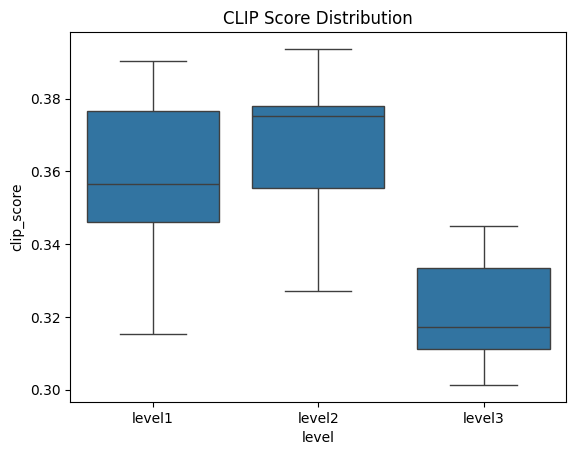

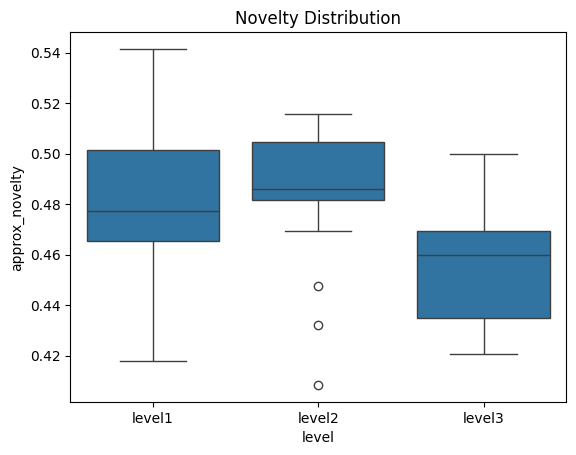

In [24]:
plt.figure()
sns.boxplot(data=df, x="level", y="clip_score")
plt.title("CLIP Score Distribution")
plt.show()

plt.figure()
sns.boxplot(data=df, x="level", y="approx_novelty")
plt.title("Novelty Distribution")
plt.show()